# Full 3D Pose Estimation Pipeline
This notebook combines 2D pose detection and 3D reconstruction steps.

In [1]:
import os
import numpy as np
from tqdm import tqdm
from ultralytics import YOLO
import pickle
from scipy.optimize import least_squares, minimize
import torch

from helpers.predictors import *
from helpers.json_handling import read_keypoints_mmpose
from helpers.camera import *
from helpers.definitions import *
from helpers.plotting import *
from helpers.pose_construction import *
from helpers.hand_transform import *
from helpers.triangulation import *
from helpers.hand_optimization import *
from helpers.sequence_optimization import optimize_sequence
from helpers.video_processing import *
from helpers.hand_detection import *
from helpers.pose_visualization import *
from helpers.weakloss import BMCLoss
import helpers.definitions



# Configuration
data_collection = 'chb/subsequence3'  # Change this to match your data collection
show = True  # Show visualizations
resolution = (960, 540)  # Processing resolution
original_resolution = (3840, 2160)  # Original video resolution
max_hands = 2  # Maximum number of hands to track per person
multiple_people = True  # Allow multiple people in the scene

FORCE_RETRAIN = False  # Force rerunning of optimization

# Camera configuration
far_field_cameras = []  # Specify which cameras to use
near_field_cameras = []  # Specify which cameras to use
for i in range(1, 12):
    if i < 5:
        far_field_cameras.append('gopro' + str(i))
    else:
        near_field_cameras.append('gopro' + str(i))

near_field_cameras.append('ORX_camera')


# Ensure the correct cameras are set up
for camera in far_field_cameras + near_field_cameras:
    if camera not in cam_names:
        print(f"Camera {camera} not found in cam_names, adding it.")
        helpers.definitions.cam_names.append(camera)

for camera in cam_names:
    if camera not in far_field_cameras and camera not in near_field_cameras:
        print(f"Camera {camera} is not assigned to any category, remvoving it.")
        cam_names.remove(camera)



Device: cuda
Torch compile enabled: True
Camera ORX_camera not found in cam_names, adding it.
Camera gopro12 is not assigned to any category, remvoving it.


## Initialize Models
Initialize all required models for detection and pose estimation.

In [2]:
# Initialize YOLO models for hand detection
model_person = YOLO('checkpoints/yolo/yolo11l.pt')
model_hand = YOLO('checkpoints/yolo/rohan_pretrained.pt')

# Configure model settings
model_hand.conf = 0.3  # NMS confidence threshold
model_hand.iou = 0.3   # NMS IoU threshold

# Initialize models with TAM tracker
USE_TAM = True
initialize_models(use_tam=USE_TAM, use_wholebody=True)

# Set up paths
data_dir = f'inputs/{data_collection}'  # Input video directory
pose_output_dir = f'pose_outputs/{data_collection}'  # 2D pose output directory
output_3d_dir = f'output_3d/{data_collection}'  # 3D pose output directory
detection_dir = f'outputs/{data_collection}'  # Directory containing detection txt files

os.makedirs(pose_output_dir, exist_ok=True)
os.makedirs(output_3d_dir, exist_ok=True)

Loads checkpoint by local backend from path: checkpoints/hands/detection/cascade_rcnn_x101_64x4d_fpn_20e_onehand10k-dac19597_20201030.pth
Loads checkpoint by local backend from path: checkpoints/body/detection/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
Disable torch compile due to unsupported GPU.
Loads checkpoint by local backend from path: checkpoints/hands/pose/rtmpose-m_simcc-hand5_pt-aic-coco_210e-256x256-74fb594_20230320.pth
Loads checkpoint by local backend from path: checkpoints/body/pose/rtmpose-x_simcc-body7_pt-body7-halpe26_700e-384x288-7fb6e239_20230606.pth
Loads checkpoint by local backend from path: checkpoints/wholebody/rtmpose-l_simcc-coco-wholebody_pt-aic-coco_270e-384x288-eaeb96c8_20230125.pth
RTMPose wholebody model initialized


c:\Users\aelvy\miniconda3\envs\orpose\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmpose.visualization.local_visualizer.PoseLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


Models initialized with EfficientTAM tracker
Pose estimation models initialized
RTMPose wholebody model ready
YOLO models initialized


## Process Videos and Extract 2D Poses

In [3]:
# Process all videos
for image_dir in os.listdir(data_dir):
    # Check if video is from an allowed camera
    if any(image_dir == cam for cam in far_field_cameras + near_field_cameras):
        # Process the video
        total_frames = process_image_sequence_wholebody(image_dir, data_dir, pose_output_dir, show=show, vis_output_dir=pose_output_dir)
    else:
        print(f'Skipping {image_dir} as it is not in the allowed camera list.')
        continue

Processing image sequence 'gopro1' with wholebody model and person tracking...
Skipping gopro1 - already processed
Processing image sequence 'gopro10' with wholebody model and person tracking...
Skipping gopro10 - already processed
Skipping gopro10_jpg as it is not in the allowed camera list.
Processing image sequence 'gopro11' with wholebody model and person tracking...
Skipping gopro11 - already processed
Skipping gopro11_jpg as it is not in the allowed camera list.
Skipping gopro1_jpg as it is not in the allowed camera list.
Processing image sequence 'gopro2' with wholebody model and person tracking...
Skipping gopro2 - already processed
Skipping gopro2_jpg as it is not in the allowed camera list.
Processing image sequence 'gopro3' with wholebody model and person tracking...
Skipping gopro3 - already processed
Skipping gopro3_jpg as it is not in the allowed camera list.
Processing image sequence 'gopro4' with wholebody model and person tracking...
Skipping gopro4 - already processed

# Match 2D Poses Across Cameras and Frames
This step matches detected instances across different cameras to identify which 2D poses correspond to the same person. This is crucial for accurate 3D reconstruction.

The matching process works in two stages:
1. **Spatial matching**: For each frame, we match poses across different camera views using triangulation and reprojection error.
2. **Temporal matching**: We track person IDs across frames by comparing 3D pose similarity between consecutive frames.

The result is a consistent set of person IDs that remain stable throughout the sequence, making it easier to track individuals over time.

In [4]:
# Load camera parameters
camera_params_dir = f'camera_poses/{data_collection.split("/")[0]}'
output_file = os.path.join(output_3d_dir, 'poses_3d.npz')

camera_intrinsics, camera_extrinsics, distortion_coeffs, camera_matrices = load_camera_params(
    os.path.join(camera_params_dir, 'camera_intrinsics'),
    os.path.join(camera_params_dir, 'camera_extrinsics/aligned_poses.json'),
    suffix='',
    named=True,
    import_extrinsics_matrix=True
)

far_field_cam_intr = [camera_intrinsics[cam] for cam in far_field_cameras]
far_field_cam_extr = [camera_extrinsics[cam] for cam in far_field_cameras]
far_field_cam_dist = [distortion_coeffs[cam] for cam in far_field_cameras]
far_field_cam_mat = [camera_matrices[cam] for cam in far_field_cameras]

In [5]:
# Get list of camera names based on pose files in the output directory
cam_names = []
for filename in os.listdir(pose_output_dir):
    if filename.endswith('_wholebody.json'):
        camera_name = filename.split('_wholebody.json')[0]
        cam_names.append(camera_name)

print(f"Found pose files for cameras: {cam_names}")

Found pose files for cameras: ['gopro10', 'gopro11', 'gopro1', 'gopro2', 'gopro3', 'gopro4', 'gopro5', 'gopro6', 'gopro7', 'gopro8', 'gopro9', 'ORX_camera']


## Enhanced Sequence-Based Cross-Camera Pose Matching

This section implements a sequence-based pose matching algorithm that:

1. **Person Sequence Extraction**: Extracts complete pose sequences for each person_id in each camera throughout the entire video
2. **Sequence-Level Matching**: Matches person IDs across camera pairs by analyzing the entire sequence at once, ensuring temporal consistency
3. **Global Person Mapping**: Creates consistent global person IDs by finding connected components across all camera pairs
4. **Quality Filtering**: Automatically filters out person instances that:
   - Don't appear consistently across enough cameras (minimum 2 by default)
   - Have insufficient pose confidence or high reprojection errors over the sequence
   - Don't maintain temporal consistency throughout the video

5. **Pairwise Optimization**: For each camera pair, finds the person ID mapping with lowest average reprojection error across the entire sequence

The key advantage is that once a person_id from camera A is matched with person_id from camera B, this mapping remains consistent throughout the entire sequence. This eliminates temporal ID switching and provides much more stable cross-camera correspondence.

In [6]:
matched_output_dir = os.path.join(pose_output_dir, 'matched_poses')

if not FORCE_RETRAIN and os.path.exists(os.path.join(matched_output_dir, 'matched_poses.json')):
    print(f"Matched poses already exist in {matched_output_dir}. Skipping matching step.")

else:
    print(f"Starting pose matching for {len(cam_names)} cameras...")
    # Apply enhanced sequence-based matching algorithm with quality filtering
    try:
        matched_file = process_and_match_poses(
            pose_output_dir,
            cam_names,
            camera_matrices,
            camera_intrinsics,
            camera_extrinsics,
            distortion_coeffs,
            matched_output_dir,
            confidence_threshold=0.3,
            reprojection_threshold=20.0,  # Higher threshold for sequence-level matching
            temporal_similarity_threshold=200.0,  # Not used in sequence-based approach
            min_matched_cameras=2  # Minimum number of cameras a person must be matched in
        )
        print(f"Successfully matched poses across cameras. Results saved to: {matched_file}")
        
        # Load the matched results to display statistics
        with open(matched_file, 'r') as f:
            matched_results = json.load(f)
        
        # Load and display enhanced matching summary statistics
        summary_file = os.path.join(matched_output_dir, 'matching_summary.json')
        if os.path.exists(summary_file):
            with open(summary_file, 'r') as f:
                summary_data = json.load(f)
            
            print("\n" + "="*60)
            print("SEQUENCE-BASED POSE MATCHING SUMMARY")
            print("="*60)
            print(f"Total frames processed: {summary_data['total_frames']}")
            print(f"Total cameras: {summary_data['total_cameras']}")
            print(f"Valid global person IDs found: {len(summary_data['valid_person_ids'])}")
            print(f"Global person IDs: {summary_data['valid_person_ids']}")
            
            print("\nPer-person statistics:")
            for person_id, stats in summary_data['person_id_statistics'].items():
                cameras_str = ', '.join(stats['cameras_seen'])
                print(f"  Global Person {person_id}: {stats['max_frame_appearances']} max frames, "
                    f"{stats['camera_count']} cameras ({cameras_str})")
            
            print(f"\nPairwise matching results:")
            if 'pairwise_matches' in summary_data:
                for pair, matches in summary_data['pairwise_matches'].items():
                    if matches:
                        print(f"  {pair}: {len(matches)} person matches")
                        for p1, p2 in matches.items():
                            print(f"    Person {p1} -> Person {p2}")
            
            print(f"\nFiltering criteria applied:")
            criteria = summary_data['filtering_criteria']
            print(f"  - Minimum cameras per person: {criteria['min_matched_cameras']}")
            print(f"  - Confidence threshold: {criteria['confidence_threshold']}")
            print(f"  - Reprojection threshold: {criteria['reprojection_threshold']} pixels")
            print("="*60)
        
        # Count number of unique persons detected per frame (on average)
        total_persons = 0
        for frame_data in matched_results:
            if 'matched_instances' in frame_data:
                total_persons += len(frame_data['matched_instances'])
        
        avg_persons = total_persons / len(matched_results) if matched_results else 0
        print(f"\nDetected an average of {avg_persons:.2f} persons per frame across {len(cam_names)} cameras.")
        
        # Count the number of persons detected in multiple cameras
        multi_cam_persons = 0
        for frame_data in matched_results:
            if 'matched_instances' in frame_data:
                for person in frame_data['matched_instances']:
                    camera_set = set()
                    for instance in person['instances']:
                        camera_set.add(instance['camera_name'])
                    if len(camera_set) > 1:
                        multi_cam_persons += 1
        
        avg_multi_cam = multi_cam_persons / len(matched_results) if matched_results else 0
        print(f"Detected an average of {avg_multi_cam:.2f} persons visible in multiple cameras per frame.")
        
        # Calculate statistics on temporal consistency
        person_id_changes = 0
        person_id_counts = {}
        
        for frame_idx, frame_data in enumerate(matched_results):
            if frame_idx == 0 or 'matched_instances' not in frame_data:
                continue
                
            # Get person IDs in current frame
            current_ids = set()
            for person in frame_data['matched_instances']:
                current_ids.add(person['person_id'])
                person_id_counts[person['person_id']] = person_id_counts.get(person['person_id'], 0) + 1
            
            # Get person IDs in previous frame
            prev_frame = matched_results[frame_idx - 1]
            if 'matched_instances' not in prev_frame:
                continue
                
            prev_ids = set()
            for person in prev_frame['matched_instances']:
                prev_ids.add(person['person_id'])
            
            # Count new IDs appearing and old IDs disappearing
            appearing_ids = current_ids - prev_ids
            disappearing_ids = prev_ids - current_ids
            
            # Only count as ID changes if there's a similar number of persons in both frames
            if abs(len(current_ids) - len(prev_ids)) <= 1:
                person_id_changes += max(len(appearing_ids), len(disappearing_ids))
        
        avg_id_changes = person_id_changes / (len(matched_results) - 1) if len(matched_results) > 1 else 0
        print(f"Average person ID changes between consecutive frames: {avg_id_changes:.2f}")
        print(f"Total number of unique person IDs across all frames: {len(person_id_counts)}")
        
        # Visualize the matched results if show flag is True
        if show:
            print("Creating visualization of matched persons...")
            
            # Check for both video files and image directories
            video_paths = {}
            for cam in cam_names:
                video_file = os.path.join(data_dir, f"{cam}.MP4")
                image_dir = os.path.join(data_dir, cam)
                
                # If video file exists, use it
                if os.path.isfile(video_file):
                    video_paths[cam] = video_file
                # If image directory exists, use it
                elif os.path.isdir(image_dir):
                    video_paths[cam] = image_dir
                else:
                    print(f"Warning: Could not find video file or image directory for camera {cam}")
            
            if video_paths:
                vis_output_dir = os.path.join(matched_output_dir, 'visualizations')
                visualization_paths = visualize_matched_persons(
                    video_paths,
                    matched_file,
                    vis_output_dir,
                    start_frame=0,
                    end_frame=300,  # Limit to first 300 frames for quick visualization
                    show_keypoints=True,
                    show_bbox=True,
                    use_png_folders=True
                )
                print(f"Visualizations saved to: {vis_output_dir}")
            else:
                print("No video files or image directories found for visualization.")

    except Exception as e:
        print(f"Error during pose matching: {str(e)}")
        import traceback
        traceback.print_exc()

Matched poses already exist in pose_outputs/chb/subsequence3\matched_poses. Skipping matching step.


## Visualize Matched Persons
The matched persons visualization overlays bounding boxes and person IDs on the original videos or image sequences. Each person is assigned a unique color across all cameras and frames, making it easy to track the same individual across different viewpoints and over time. The visualization shows:

1. Bounding boxes around each person with their unique ID
2. Skeleton keypoints showing the body pose
3. Connections between keypoints to form a full-body skeleton

This visualization helps verify that our matching algorithm is correctly identifying the same person across different camera views and throughout the sequence. The system automatically detects whether to use video files (.MP4) or image sequences (folders with PNG/JPG files) as input.

The temporal matching ensures that the same person ID is consistently assigned to the same individual across frames, which is essential for tracking and motion analysis. Statistics about ID consistency are displayed to quantify the effectiveness of the temporal matching.

## Reconstruct 3D Poses
Load 2D poses and camera parameters, then reconstruct 3D poses.

In [7]:
# Step 4: 3D Pose Reconstruction with Multi-Person Support
print("Step 4: 3D Pose Reconstruction")

matched_poses_file = os.path.join(matched_output_dir, 'matched_poses.json')

# Check if we're using matched poses for multi-person reconstruction
if multiple_people and os.path.exists(matched_poses_file):
    print("Using matched poses for multi-person reconstruction...")
    
    # Load 2D pose data
    print("Loading 2D pose data...")
    poses_2d_body_multi, poses_2d_hands_multi = read_keypoints_mmpose(pose_output_dir, cam_names, total_frames, far_field_cameras, multi_person=True, matched_poses_path=matched_poses_file)
    print(f"Found {len(poses_2d_body_multi)} persons in matched poses.")
    
    if len(poses_2d_body_multi) > 0:
        poses_3d_body_multi = {}
        
        # Process each person using confidence-weighted reconstruction (no explicit masking)
        for person_id, person_poses in poses_2d_body_multi.items():
            print(f"Reconstructing 3D poses for person {person_id}...")
            
            # # Use the new confidence-weighted function that doesn't do explicit masking
            poses_3d_body_multi[person_id] = reconstruct_3d_pose_weighted(
                person_poses,  # poses with confidence values
                far_field_cam_intr,
                far_field_cam_extr,
                far_field_cam_dist,
                far_field_cam_mat,
                confidence_threshold=0.3,  # Lower threshold since we're using confidence weighting
                min_cameras=2,
                regularization_weight=1.0,
                reprojection_weight=1.0,
                return_init=False,
                only_init=False,
                split_opt=None,
                smoothing=False,
                use_torch=True,
                exhaustive_search=True  # Enable exhaustive search for better triangulation
            )
        
        poses_3d_body = poses_3d_body_multi
        
        # Save multi-person data as pickle files
        print("Saving multi-person data as pickle files...")
        with open(os.path.join(output_3d_dir, 'poses_3d_multi.pkl'), 'wb') as f:
            pickle.dump(poses_3d_body_multi, f)
        
        # Create multi-person visualization
        multi_person_video_path = pose2video(
            poses_3d_body_multi, 
            output_3d_dir, 
            cam_names, 
            camera_matrices, 
            camera_intrinsics, 
            camera_extrinsics, 
            distortion_coeffs, 
            multi_person=True,
        )
        print(f"Multi-person video saved: {multi_person_video_path}")
        
    else:
        print("No matched poses found for multi-person reconstruction")
        poses_3d_body = {}

else:
    # Single person reconstruction using the original method with masking
    if multiple_people:
        print("Multi-person mode enabled but no matched poses found, switching to single person mode...")
    
    print("Single person 3D pose reconstruction...")
    
    # Mask keypoints based on confidence and camera visibility for single person
    print("Loading 2D pose data...")
    poses_2d_body = read_keypoints_mmpose(pose_output_dir, cam_names, total_frames, far_field_cameras, multi_person=False)
    masked_poses = mask_keypoints(poses_2d_body, confidence_threshold=0.5, min_cameras=2, multi_person=False)
    
    # Original single-person reconstruction
    poses_3d_body = reconstruct_3d_pose(
        masked_poses,
        far_field_cam_intr,
        far_field_cam_extr,
        far_field_cam_dist,
        far_field_cam_mat,
        regularization_weight=1.0,
        reprojection_weight=1.0,
        return_init=False,
        only_init=False,
        split_opt=None,
        smoothing=False,
        use_torch=True,
        multi_person=False
    )
    
    # Save single-person data as numpy file
    print("Saving single-person data as numpy files...")
    np.savez(
        os.path.join(output_3d_dir, 'poses_3d.npz'),
        poses_3d=poses_3d_body
    )
    
    # Create single-person visualization
    single_person_video_path = pose2video(
        poses_3d_body, 
        output_3d_dir, 
        cam_names, 
        camera_matrices, 
        camera_intrinsics, 
        camera_extrinsics, 
        distortion_coeffs, 
        multi_person=False
    )
    print(f"Single-person video saved: {single_person_video_path}")

print("3D pose reconstruction completed!")

Step 4: 3D Pose Reconstruction
Using matched poses for multi-person reconstruction...
Loading 2D pose data...
Found 3 persons in matched poses.
Reconstructing 3D poses for person 0...


TypeError: LBFGS.step() missing 1 required positional argument: 'closure'

## Hand Detection and Tracking
Using pre-trained YOLO models for person and hand detection, followed by hand pose estimation and tracking. The system first detects persons using YOLOv8, then searches for hands within detected person regions using a specialized hand detection model.

In [ ]:
# Process all videos in the inputs folder
for video_file in os.listdir(data_dir):
    if video_file.endswith('.MP4'):
        video_name = os.path.splitext(video_file)[0]
        if any(video_name.startswith(cam) for cam in near_field_cameras):
            print(f"\nProcessing video: {video_name}")
            video_path = os.path.join(data_dir, video_file)

            if os.path.exists(f"outputs/{data_collection}/{video_name}.txt"):
                print("Output already exists, skipping")
                continue
            # Process the video
            #bboxes = process_video_rohan(video_path, model_person, model_hand, show=show)
            bboxes = process_video_wholebody_hands(video_name, data_dir=data_dir, pose_dir=pose_output_dir, save_dir=detection_dir, show=show)
            
            if len(bboxes) == 0:
                print("No hands detected")
            else:
                (boxes, conf, frame_idxs) = zip(*bboxes)
                print(f"\nFound hands at frame {frame_idxs}")
                print(f"Bounding boxes: \n{boxes}")

                os.makedirs(f"outputs/{data_collection}", exist_ok=True)
                save_to_file(bboxes, f"outputs/{data_collection}/{video_name}.txt")

## Hand Tracking with EfficientTAM
This section handles hand tracking using the EfficientTAM algorithm. The process first detects people and hands using YOLO models, then uses EfficientTAM to track detected hands through video sequences. This enables robust hand tracking even with rapid movements and partial occlusions.

In [ ]:
# Process near field cameras for hand poses
hand_poses_2d = {}
output_file = os.path.join(output_3d_dir, 'hand_poses_2d.npz')
if os.path.exists(output_file):
    print("Hand poses already found, skipping")
    hand_poses_2d = np.load(output_file, allow_pickle=True)['poses_2d'].item()
    
else:
    for video_file in os.listdir(data_dir):
        if video_file.endswith('.MP4'):
            video_name = os.path.splitext(video_file)[0]
            if any(video_name.startswith(cam) for cam in near_field_cameras):
                cam_name = video_name.split('_')[0]
                print(f"\nProcessing {video_name} for hand detection and tracking...")
                video_path = os.path.join(data_dir, video_file)
                
                if os.path.exists(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl")):
                    print(f"Tracks already found for {video_name}")

                    with open(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl"), 'rb') as f:
                        tracks = pickle.load(f)

                else:
                    # Track hands
                    tracks, frame_names = process_video_wholebody_hands_for_tracking(
                        video_name, 
                        data_dir, 
                        detection_dir, 
                        resolution, 
                        original_resolution, 
                        max_hands, 
                        show=show,
                        add_object_fn=add_object,
                        track_object_fn=track_object
                    )

                    if tracks is not None:
                        # Save tracked boxes
                        with open(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl"), 'wb') as f:
                            tracks = adjust_tracks(tracks, resolution, original_resolution)
                            pickle.dump(tracks, f)
                
                if tracks is not None: 
                    # Process and visualize poses with multi-person support
                    if multiple_people:
                        # For multi-person mode, we'll process each person separately
                        # For now, default to the first person if multiple people exist
                        default_person_id = list(poses_3d_body.keys())[0] if isinstance(poses_3d_body, dict) else None
                        hand_poses_2d[cam_name] = process_and_visualize_poses(
                            video_path, 
                            tracks, 
                            pose_output_dir,
                            poses_3d_body,
                            camera_matrices,
                            camera_intrinsics,
                            camera_extrinsics,
                            distortion_coeffs,
                            hide_legs=True,
                            create_label_poses=True,
                            multi_person=True,
                            person_id=default_person_id
                        )
                    else:
                        hand_poses_2d[cam_name] = process_and_visualize_poses(
                            video_path, 
                            tracks, 
                            pose_output_dir,
                            poses_3d_body,
                            camera_matrices,
                            camera_intrinsics,
                            camera_extrinsics,
                            distortion_coeffs,
                            hide_legs=True,
                            create_label_poses=True,
                            multi_person=False
                        )

    # Save hand poses to file
    np.savez(
        output_file,
        poses_2d=hand_poses_2d,
    )


Processing gopro10_synced_cut for hand detection and tracking...
Tracks already found for gopro10_synced_cut


c:\Users\aelvy\miniconda3\envs\orpose\Lib\site-packages\mmdet\models\layers\se_layer.py:158: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
c:\Users\aelvy\miniconda3\envs\orpose\Lib\site-packages\mmdet\models\backbones\csp_darknet.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):



Processing gopro11_synced_cut for hand detection and tracking...
Tracks already found for gopro11_synced_cut

Processing gopro12_synced_cut for hand detection and tracking...
Tracks already found for gopro12_synced_cut

Processing gopro5_synced_cut for hand detection and tracking...
Tracks already found for gopro5_synced_cut

Processing gopro6_synced_cut for hand detection and tracking...
Tracks already found for gopro6_synced_cut

Processing gopro7_synced_cut for hand detection and tracking...
Tracks already found for gopro7_synced_cut

Processing gopro8_synced_cut for hand detection and tracking...
Tracks already found for gopro8_synced_cut

Processing gopro9_synced_cut for hand detection and tracking...
Tracks already found for gopro9_synced_cut


## Hand Pose Reconstruction Methods

This notebook supports four different approaches for reconstructing 3D hand poses from 2D observations:

1. **BMC-based Optimization (Original Method)**: Uses a biomechanically constrained (BMC) loss function to optimize hand poses, along with weighted reprojection error and temporal consistency

2. **Weighted Triangulation**: Reconstructs hand poses using weighted triangulation similar to the body keypoint reconstruction, using keypoint confidence scores as weights

3. **Optimization without BMC**: Optimizes hand poses using only weighted reprojection error and temporal consistency, without biomechanical constraints

4. **Sequence Optimization**: Optimizes the entire sequence at once using LBFGS to maintain better temporal consistency across frames

Each method builds upon the same initial hand poses, which are created by applying canonical hand poses to the wrist positions from the body model.

## Hand-ID Matching using Wholebody Pose Estimation

This section implements a function to match tracked hand object IDs with their correct hand sides (left/right) based on wholebody pose estimation. The function compares tracked hands with wholebody hands or canonical hand projections to determine consistent ID mapping across the video sequence.

In [ ]:
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_id_mapping.pkl')):
    print("Hand ID mapping already exists, loading...")
    with open(os.path.join(output_3d_dir, 'hand_id_mapping.pkl'), 'rb') as f:
        hand_id_mapping = pickle.load(f)
else:
    print("Identifying hand IDs...")

    # Prepare video paths dictionary for the identify_hand_ids function
    video_paths = {}
    for cam_name in hand_poses_2d.keys():
        video_paths[cam_name] = os.path.join(data_dir, f"{cam_name}_synced_cut.MP4")

    # Run hand ID identification with multi-person support
    if multiple_people:
        # For multi-person mode, we need to identify hands for each person
        hand_id_mapping = {}
        
        # For now, use the first person as default for hand ID mapping
        # In a full implementation, you might want to identify hands for each person separately
        default_person_id = list(poses_3d_body.keys())[0] if isinstance(poses_3d_body, dict) else None
        
        if default_person_id is not None:
            hand_id_mapping = identify_hand_ids(
                hand_poses_2d,
                video_paths,
                camera_intrinsics,
                camera_extrinsics,
                distortion_coeffs,
                poses_3d_body,
                num_frames=None,  # Process all frames available
                visualize=True,  # Set to True to see visual matches
                pose_output_dir=pose_output_dir,
                multi_person=True,
                person_id=default_person_id
            )
        else:
            print("No persons found in poses_3d_body for multi-person mode")
            hand_id_mapping = {}
    else:
        # Single-person mode
        hand_id_mapping = identify_hand_ids(
            hand_poses_2d,
            video_paths,
            camera_intrinsics,
            camera_extrinsics,
            distortion_coeffs,
            poses_3d_body,
            num_frames=None,  # Process all frames available
            visualize=True,  # Set to True to see visual matches
            pose_output_dir=pose_output_dir,
            multi_person=False
        )

    # Save the hand ID mapping
    with open(os.path.join(output_3d_dir, 'hand_id_mapping.pkl'), 'wb') as f:
        pickle.dump(hand_id_mapping, f)

# Update the hand tracking and optimization functions to use this mapping
print("\nHand ID mapping:")
for cam_name, mapping in hand_id_mapping.items():
    print(f"Camera {cam_name}:")
    for obj_id, hand_side in mapping.items():
        print(f"  Object ID {obj_id} -> {'Left' if hand_side == 0 else 'Right'} hand")

Hand ID mapping already exists, loading...

Hand ID mapping:
Camera gopro10:
  Object ID 0 -> Left hand
  Object ID 1 -> Right hand
Camera gopro11:
  Object ID 0 -> Left hand
  Object ID 1 -> Right hand
Camera gopro12:
  Object ID 0 -> Left hand
  Object ID 1 -> Right hand
Camera gopro5:
Camera gopro6:
  Object ID 0 -> Left hand
  Object ID 1 -> Right hand
Camera gopro7:
  Object ID 0 -> Left hand
  Object ID 1 -> Right hand
Camera gopro8:
  Object ID 1 -> Left hand
  Object ID 0 -> Right hand
Camera gopro9:
  Object ID 0 -> Right hand


In [ ]:
from scipy.signal import savgol_filter

# Use the hand_id_mapping in match_hand_poses function by adding the mapping parameter
# This will ensure hands are correctly matched during optimization process

# Get the appropriate body poses for hand optimization
if multiple_people:
    # For multi-person mode, use the first person as default
    # In a full implementation, you might optimize hands for each person separately
    default_person_id = list(poses_3d_body.keys())[0] if isinstance(poses_3d_body, dict) else None
    if default_person_id is not None:
        current_poses_3d_body = poses_3d_body[default_person_id]
        print(f"Using person {default_person_id} for hand pose optimization")
    else:
        print("No persons found in poses_3d_body for multi-person mode")
        current_poses_3d_body = []
else:
    current_poses_3d_body = poses_3d_body

# Method 1: Triangulation method with hand ID mapping
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_triangulation_mapped.npz')):
    print("Triangulated hand poses already found with mapping, skipping")
    smoothed_triangulated_hands = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_triangulation_mapped.npz'))['poses_3d']

else:
    triangulated_hand_poses_3d_with_mapping = []
    for frame_idx in range(len(current_poses_3d_body)):
        # Triangulate hand keypoints for this frame with ID mapping
        if multiple_people:
            hand_3d = triangulate_hand_keypoints(
                hand_poses_2d,
                camera_intrinsics,
                camera_extrinsics,
                camera_matrices,
                distortion_coeffs,
                poses_3d_body,  # Pass the full dict
                frame_idx,
                hand_id_mapping=hand_id_mapping,
                multi_person=True,
                person_id=default_person_id
            )
        else:
            hand_3d = triangulate_hand_keypoints(
                hand_poses_2d,
                camera_intrinsics,
                camera_extrinsics,
                camera_matrices,
                distortion_coeffs,
                current_poses_3d_body,
                frame_idx,
                hand_id_mapping=hand_id_mapping,
                multi_person=False
            )
        triangulated_hand_poses_3d_with_mapping.append(hand_3d)
        print(f"Triangulated hand pose with mapping for frame {frame_idx}: {hand_3d.shape}")

    triangulated_hand_poses_3d_with_mapping = np.array(triangulated_hand_poses_3d_with_mapping)

    print(triangulated_hand_poses_3d_with_mapping.shape)

    triangulated_hand_poses_3d_with_mapping = interpolate_keypoints(triangulated_hand_poses_3d_with_mapping)

    # Apply temporal smoothing to reduce jitter
    smoothed_triangulated_hands = savgol_filter(triangulated_hand_poses_3d_with_mapping, 
                                            window_length=15,  # Must be odd and <= num_frames
                                            polyorder=3,
                                            axis=0)

    # Save results for triangulation with mapping
    output_file_triangulation_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_triangulation_mapped.npz')
    np.savez(
        output_file_triangulation_mapped,
        poses_3d=smoothed_triangulated_hands,
    )

# Method 2: No-BMC Optimization with hand ID mapping
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc_mapped.npz')):
    print("No-BMC optimized hand poses already found with mapping, skipping")
    nobmc_optimized_hand_poses_3d = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc_mapped.npz'))['poses_3d']

else:
    nobmc_optimized_hand_poses_3d = []

    for frame_idx in range(len(current_poses_3d_body)):
        if frame_idx == 0:
            # For first frame, use initial hand poses
            initial_pose = np.concatenate([
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, current_poses_3d_body[frame_idx], side='left'),
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, current_poses_3d_body[frame_idx], side='right')
            ])
            
            # Optimize without BMC but with hand ID mapping
            optimized_hand = optimize_poses_no_bmc(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs,
                frame_idx=frame_idx, hand_id_mapping=hand_id_mapping  # Add mapping here
            )
            nobmc_optimized_hand_poses_3d.append(optimized_hand)
            prev_optimized_hand = optimized_hand
        else:
            # For subsequent frames, initialize hands from previous optimized pose
            left_hand = initialize_hand_pose_for_next_frame(
                prev_optimized_hand[:num_keypoints_hands], 
                current_poses_3d_body[frame_idx], 
                current_poses_3d_body[frame_idx-1], 
                side='left'
            )
            right_hand = initialize_hand_pose_for_next_frame(
                prev_optimized_hand[num_keypoints_hands:], 
                current_poses_3d_body[frame_idx], 
                current_poses_3d_body[frame_idx-1], 
                side='right'
            )

            # Concatenate left and right hand poses
            initial_pose = np.concatenate([left_hand, right_hand])
            
            # Optimize without BMC but with hand ID mapping
            optimized_hand = optimize_poses_no_bmc(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs,
                frame_idx=frame_idx, previous_pose=prev_optimized_hand,
                hand_id_mapping=hand_id_mapping  # Add mapping here
            )
            nobmc_optimized_hand_poses_3d.append(optimized_hand)
            prev_optimized_hand = optimized_hand
            
        print(f"No-BMC optimized hand pose with mapping for frame {frame_idx}: {optimized_hand.shape}")

    nobmc_optimized_hand_poses_3d = np.array(nobmc_optimized_hand_poses_3d)

    # Save results for No-BMC optimization with mapping
    output_file_nobmc_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc_mapped.npz')
    np.savez(
        output_file_nobmc_mapped,
        poses_3d=nobmc_optimized_hand_poses_3d,
    )

# Method 3: BMC-based Optimization
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_bmc_mapped.npz')):
    print("Hand poses already found with mapping, skipping")
    optimized_hand_poses_3d = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_bmc_mapped.npz'))['poses_3d']
else:
    optimized_hand_poses_3d = []
    for frame_idx in range(len(current_poses_3d_body)):
        if frame_idx == 0:
            initial_pose = np.concatenate([
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, current_poses_3d_body[frame_idx], side='left'),
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, current_poses_3d_body[frame_idx], side='right')
            ])
            # Optimize hand poses with ID mapping
            optimized_hand = optimize_poses(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs, 
                frame_idx=frame_idx, visualize=False, input_dir=data_dir,
                hand_id_mapping=hand_id_mapping  # Add the mapping here
            )
            optimized_hand_poses_3d.append(optimized_hand)
            prev_optimized_hand = optimized_hand
        else:

            # For subsequent frames, initialize hands from previous optimized pose
            left_hand = initialize_hand_pose_for_next_frame(
                prev_optimized_hand[:num_keypoints_hands], 
                current_poses_3d_body[frame_idx], 
                current_poses_3d_body[frame_idx-1], 
                side='left'
            )
            right_hand = initialize_hand_pose_for_next_frame(
                prev_optimized_hand[num_keypoints_hands:], 
                current_poses_3d_body[frame_idx], 
                current_poses_3d_body[frame_idx-1], 
                side='right'
            )
            initial_pose = np.concatenate([left_hand, right_hand])
            # Optimize subsequent frames with ID mapping
            optimized_hand = optimize_poses(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs, 
                frame_idx=frame_idx, previous_pose=prev_optimized_hand,
                visualize=False, input_dir=data_dir,
                hand_id_mapping=hand_id_mapping  # Add the mapping here
            )
            if np.isnan(optimized_hand).any():
                optimized_hand_poses_3d.append(prev_optimized_hand)
            else:
                optimized_hand_poses_3d.append(optimized_hand)
                prev_optimized_hand = optimized_hand
        
        print(f"Optimized hand pose with mapping for frame {frame_idx}: {optimized_hand.shape}")

    # Convert to numpy array
    optimized_hand_poses_3d = np.array(optimized_hand_poses_3d)

    # Save results with correct mapping
    output_file_bmc_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_bmc_mapped.npz')
    np.savez(
        output_file_bmc_mapped,
        poses_3d=optimized_hand_poses_3d,
    )

# Method 4: Sequence Optimization with hand ID mapping (No-BMC)
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_sequence_mapped.npz')):
    print("Sequence-optimized hand poses already found with mapping, skipping")
    sequence_optimized_hand_poses_3d = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_sequence_mapped.npz'))['poses_3d']
else:
    # Create initial poses based on canonical hand poses
    initial_sequence = []
    for frame_idx in range(len(current_poses_3d_body)):
        initial_pose = np.concatenate([
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, current_poses_3d_body[frame_idx], side='left'),
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, current_poses_3d_body[frame_idx], side='right')
        ])
        initial_sequence.append(initial_pose)
        if np.isnan(initial_pose).any():
            print(f"Initial pose for frame {frame_idx} contains NaN values")
            print(current_poses_3d_body[frame_idx][6], current_poses_3d_body[frame_idx][8], current_poses_3d_body[frame_idx][10])
            print(current_poses_3d_body[frame_idx][5], current_poses_3d_body[frame_idx][7], current_poses_3d_body[frame_idx][9])
    initial_sequence = np.array(initial_sequence)

    
    # Interpolate missing keypoints
    initial_sequence = interpolate_keypoints(initial_sequence)
    
    # Apply sequence optimization
    print("Starting sequence optimization...")
    sequence_optimized_hand_poses_3d = optimize_sequence(
        initial_sequence,
        hand_poses_2d,
        camera_intrinsics,
        camera_extrinsics,
        distortion_coeffs,
        current_poses_3d_body,
        hand_id_mapping=hand_id_mapping,
        use_bmc=False,  # Can be set to True to use BMC constraints
        lambdas=[1.0, 1.0, 1.0, 1.0, 1.0]  # [reprojection, temporal, spatial, bmc, shape]
    )
    
    # Save results with correct mapping
    output_file_sequence_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_sequence_mapped.npz')
    np.savez(
        output_file_sequence_mapped,
        poses_3d=sequence_optimized_hand_poses_3d,
    )

if not os.path.exists(os.path.join(output_3d_dir, 'visualization_triangulated_hands_mapped')):
    
    # Visualize all four methods with correct mapping
    # Use appropriate body poses for visualization
    viz_body_poses = current_poses_3d_body if not multiple_people else poses_3d_body
    
    if multiple_people:
        # For multi-person mode, visualize with the specific person
        pose2video(
            viz_body_poses,
            output_3d_dir,
            'visualization_triangulated_hands_mapped',
            smoothed_triangulated_hands,
            render_body=False,
            dynamic_limits=True,
            multi_person=True,
            person_id=default_person_id
        )

        pose2video(
            viz_body_poses,
            output_3d_dir,
            'visualization_nobmc_hands_mapped',
            nobmc_optimized_hand_poses_3d,
            render_body=False,
            dynamic_limits=True,
            multi_person=True,
            person_id=default_person_id
        )

        pose2video(
            viz_body_poses,
            output_3d_dir,
            'visualization_bmc_hands_mapped',
            optimized_hand_poses_3d,
            render_body=False,
            dynamic_limits=True,
            multi_person=True,
            person_id=default_person_id
        )

        pose2video(
            viz_body_poses,
            output_3d_dir,
            'visualization_sequence_hands_mapped',
            sequence_optimized_hand_poses_3d,
            render_body=False,
            dynamic_limits=True,
            multi_person=True,
            person_id=default_person_id
        )
    else:
        # Single-person mode
        pose2video(
            viz_body_poses,
            output_3d_dir,
            'visualization_triangulated_hands_mapped',
            smoothed_triangulated_hands,
            render_body=False,
            dynamic_limits=True
        )

        pose2video(
            viz_body_poses,
            output_3d_dir,
            'visualization_nobmc_hands_mapped',
            nobmc_optimized_hand_poses_3d,
            render_body=False,
            dynamic_limits=True
        )

        pose2video(
            viz_body_poses,
            output_3d_dir,
            'visualization_bmc_hands_mapped',
            optimized_hand_poses_3d,
            render_body=False,
            dynamic_limits=True
        )

        pose2video(
            viz_body_poses,
            output_3d_dir,
            'visualization_sequence_hands_mapped',
            sequence_optimized_hand_poses_3d,
            render_body=False,
            dynamic_limits=True
        )

# Create a dictionary of all hand pose methods with mapping for comparison
hand_poses_methods_mapped = {
   
    'Triangulation': smoothed_triangulated_hands,
    'No-BMC_Optimization': nobmc_optimized_hand_poses_3d,
    'BMC_Optimization': optimized_hand_poses_3d,
    'Sequence_Optimization': sequence_optimized_hand_poses_3d
}

# Create reprojection videos comparing the mapped methods
create_reprojection_videos(
    current_poses_3d_body,
    hand_poses_methods_mapped,
    camera_intrinsics,
    camera_extrinsics,
    distortion_coeffs,
    data_dir,
    os.path.join(output_3d_dir, 'comparisons'),
    camera_angles=['gopro10', 'gopro8', 'gopro7'],  # Specify which cameras to use
    hide_legs=True
)

# Example usage with viewpoint comparison
# create_reprojection_videos(
#     current_poses_3d_body,
#     hand_poses_methods_mapped,  # Dictionary of hand pose methods
#     camera_intrinsics,
#     camera_extrinsics,
#     distortion_coeffs,
#     data_dir,    
#     os.path.join(output_3d_dir, 'viewpoint_comparisons'),
#     camera_angles=['gopro10', 'gopro8', 'gopro7'],  # Specify which cameras to use
#     hide_legs=True,
#     compare_viewpoints=True,  # Enable viewpoint comparison mode
#     hand_id_mapping=hand_id_mapping  # Pass the hand ID mapping for viewpoint counts
# )

Triangulated hand poses already found with mapping, skipping
Initial Loss (no BMC):
Reprojection loss: 28778.2421875
Temporal loss: 0.0
Shape loss: 0.0
Total loss: 28778.2421875
Final loss (no BMC):
Reprojection loss: 14347.6650390625
Temporal loss: 0.0
Shape loss: 0.0
Total loss: 14347.6650390625
Initial Loss (no BMC):
Reprojection loss: 171055.953125
Temporal loss: 0.0
Shape loss: 0.0
Total loss: 171055.953125
Final loss (no BMC):
Reprojection loss: 119147.15625
Temporal loss: 0.0
Shape loss: 0.0
Total loss: 119147.15625
No-BMC optimized hand pose with mapping for frame 0: (42, 3)
Initial Loss (no BMC):
Reprojection loss: 99345.453125
Temporal loss: 0.09526880085468292
Shape loss: 0.05384020134806633
Total loss: 99345.53125
Final loss (no BMC):
Reprojection loss: 40202.37109375
Temporal loss: 10.076740264892578
Shape loss: 10.019299507141113
Total loss: 40212.41796875
Initial Loss (no BMC):
Reprojection loss: 8326548.5
Temporal loss: 0.10433723777532578
Shape loss: 0.0804346948862075

KeyboardInterrupt: 

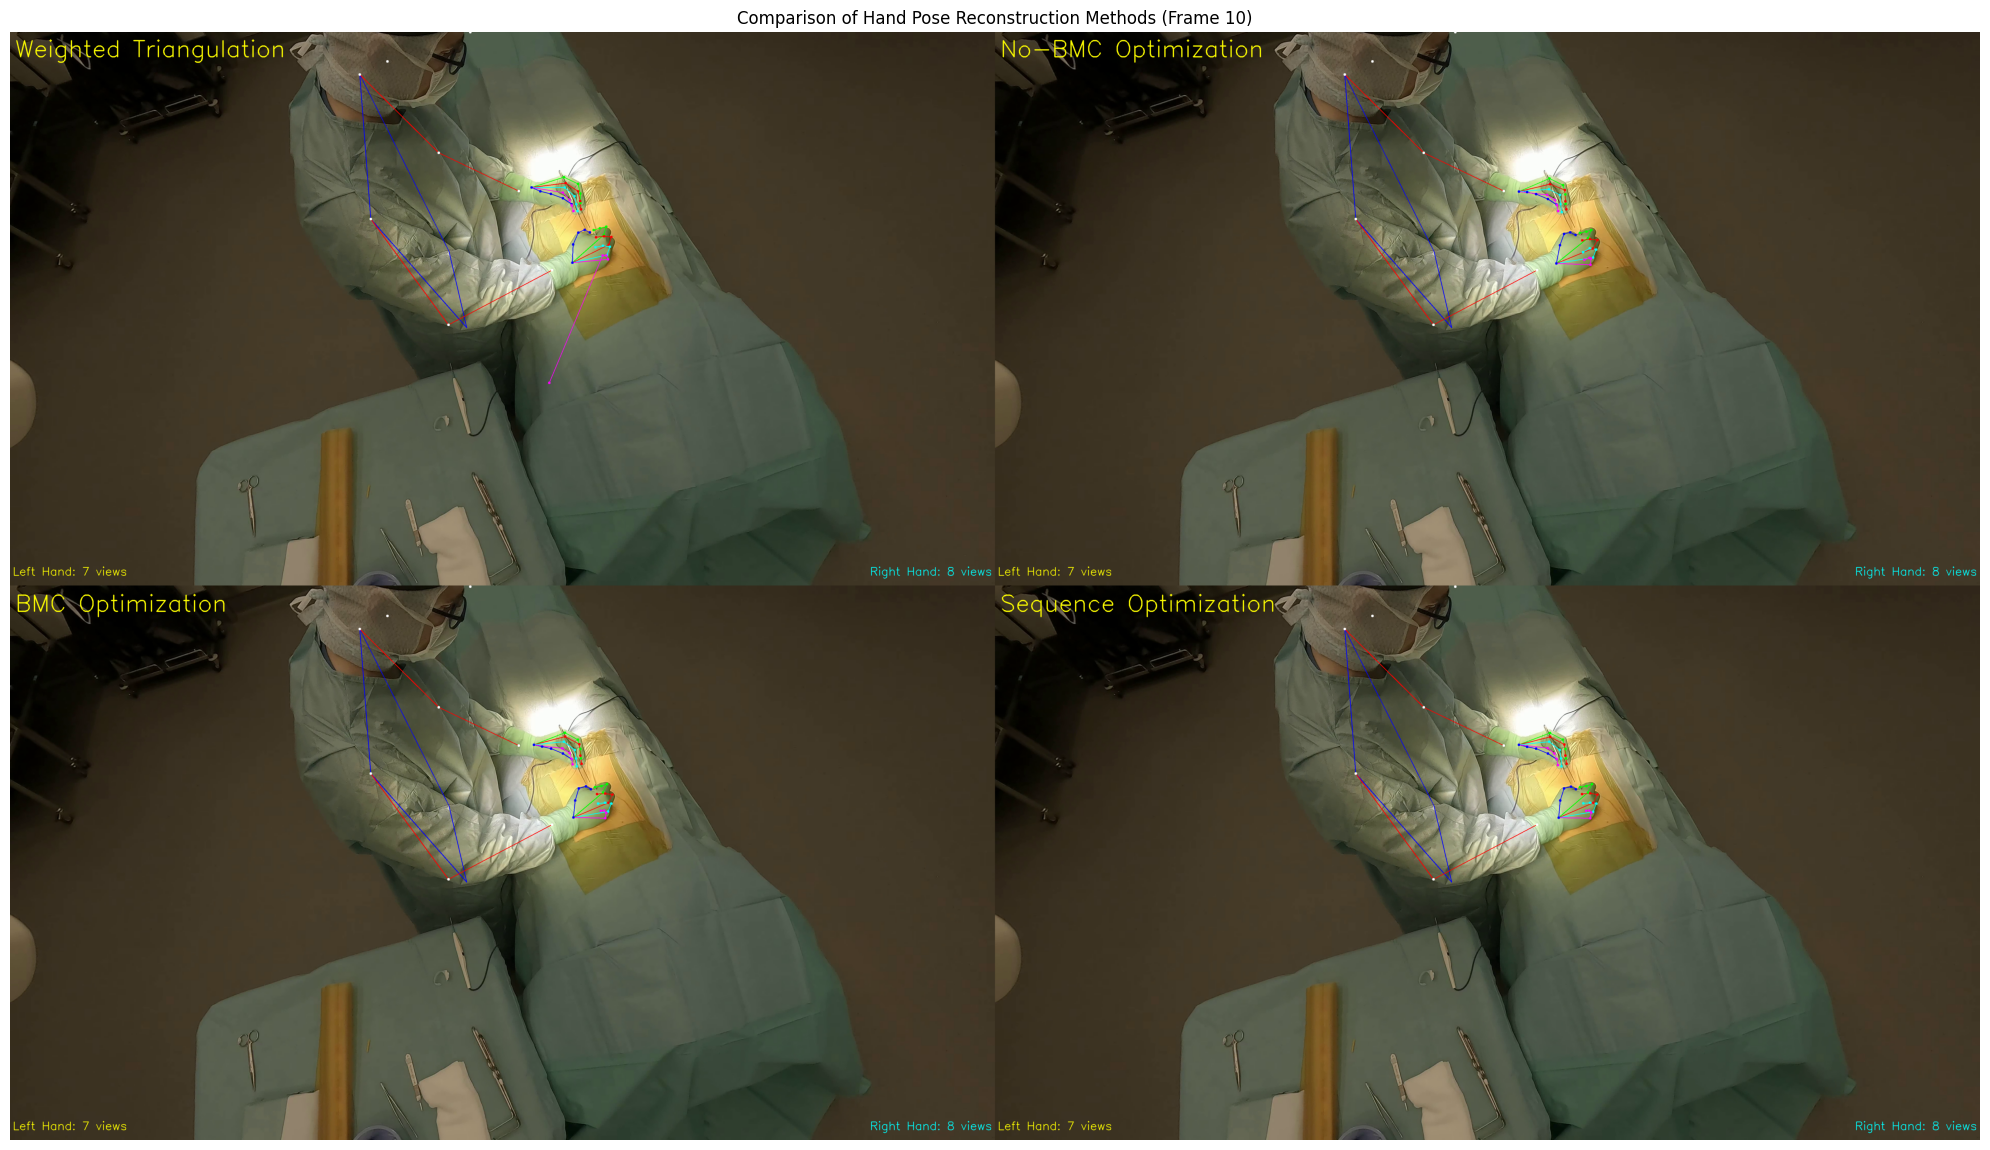

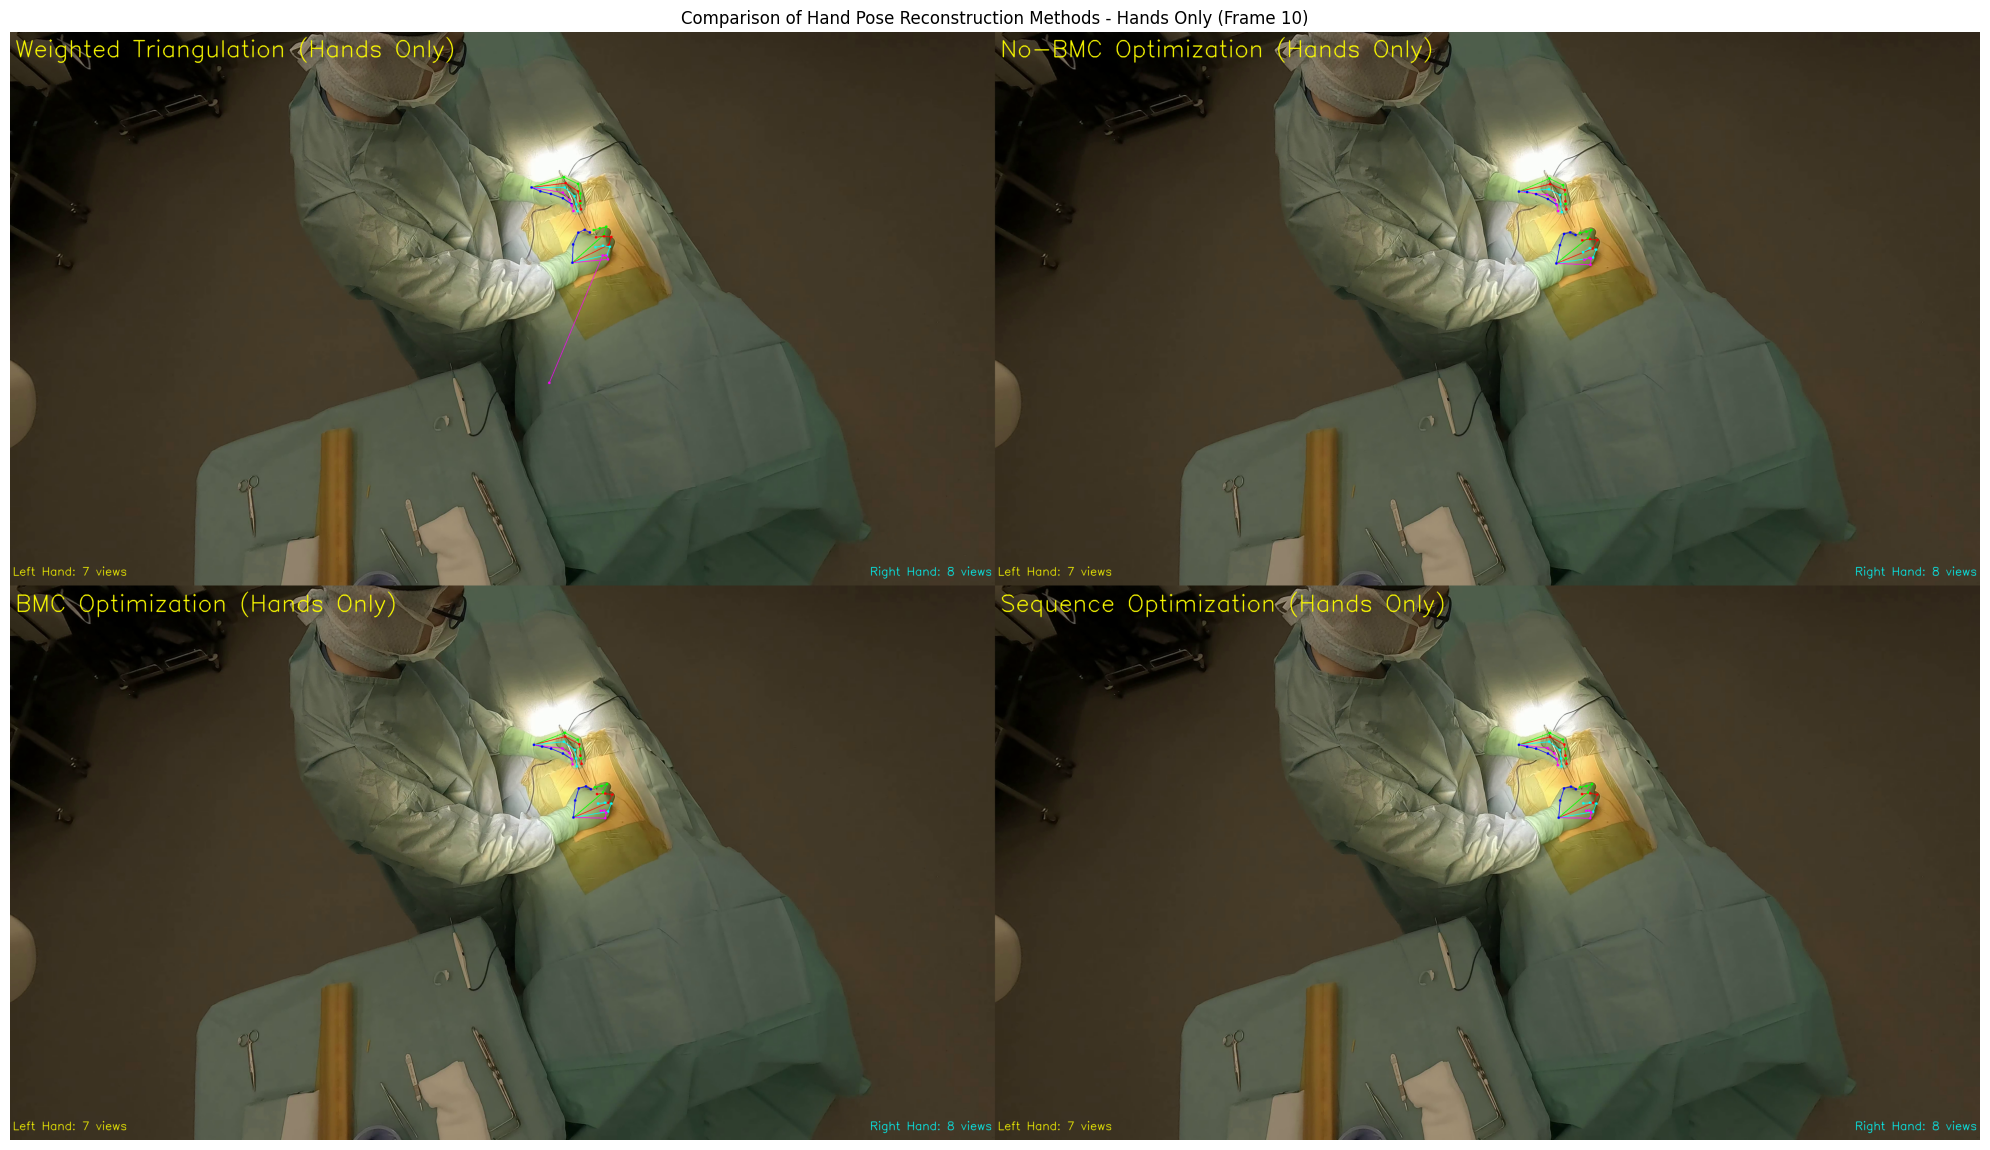

Quantitative Evaluation of Hand Pose Reconstruction Methods:
--------------------------------------------------------------------------------
Method                    Reprojection Error (px)   Temporal Smoothness      
--------------------------------------------------------------------------------
Triangulation             17.13                     0.0000                   
No-BMC Optimization       5.71                      0.0029                   
BMC Optimization          6.18                      0.0026                   
Sequence Optimization     6.18                      0.0019                   
--------------------------------------------------------------------------------
Notes:
- Lower reprojection error means better alignment with 2D observations
- Lower temporal smoothness value means smoother motion (less jitter)


In [ ]:
# Compare visualizations of the four methods on a sample frame
camera = 'gopro8'
frame_idx = 10  # Choose a frame for comparison

video_path = os.path.join(data_dir, f'{camera}_synced_cut.MP4')
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()
cap.release()

if ret:
    # Get camera parameters
    cam_intrinsics = camera_intrinsics[camera].reshape(3,3)
    cam_extrinsics = camera_extrinsics[camera]
    cam_distortion = distortion_coeffs[camera]
    
    # Get the appropriate body pose for this frame
    if multiple_people:
        # Use the same person as in optimization
        default_person_id = list(poses_3d_body.keys())[0] if isinstance(poses_3d_body, dict) else None
        if default_person_id is not None and frame_idx < len(poses_3d_body[default_person_id]):
            frame_body_pose = poses_3d_body[default_person_id][frame_idx]
        else:
            frame_body_pose = None
    else:
        if frame_idx < len(poses_3d_body):
            frame_body_pose = poses_3d_body[frame_idx]
        else:
            frame_body_pose = None
    
    # Create visualizations for each method with body pose
    frame_bmc = visualize_poses(frame.copy(), frame_body_pose, optimized_hand_poses_3d[frame_idx], 
                              hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                              cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_triang = visualize_poses(frame.copy(), frame_body_pose, smoothed_triangulated_hands[frame_idx], 
                                 hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                 cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_nobmc = visualize_poses(frame.copy(), frame_body_pose, nobmc_optimized_hand_poses_3d[frame_idx], 
                                hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_sequence = visualize_poses(frame.copy(), frame_body_pose, sequence_optimized_hand_poses_3d[frame_idx], 
                                   hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                   cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    # Create visualizations for each method with only hands (no body)
    frame_bmc_hands = visualize_poses(frame.copy(), None, optimized_hand_poses_3d[frame_idx], 
                                    hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                    cam_distortion, frame_idx, camera, draw_body=False, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_triang_hands = visualize_poses(frame.copy(), None, smoothed_triangulated_hands[frame_idx], 
                                       hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                       cam_distortion, frame_idx, camera, draw_body=False, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_nobmc_hands = visualize_poses(frame.copy(), None, nobmc_optimized_hand_poses_3d[frame_idx], 
                                      hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                      cam_distortion, frame_idx, camera, draw_body=False, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_sequence_hands = visualize_poses(frame.copy(), None, sequence_optimized_hand_poses_3d[frame_idx], 
                                         hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                         cam_distortion, frame_idx, camera, draw_body=False, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    # Add clear method labels to the frames
    label_params = {
        'fontFace': cv2.FONT_HERSHEY_SIMPLEX,
        'org': (20, 100),
        'fontScale': 3.0,
        'color': (0, 255, 255),  # Yellow
        'thickness': 3,
    }
    
    cv2.putText(frame_bmc, "BMC Optimization", **label_params)
    cv2.putText(frame_triang, "Weighted Triangulation", **label_params)
    cv2.putText(frame_nobmc, "No-BMC Optimization", **label_params)
    cv2.putText(frame_sequence, "Sequence Optimization", **label_params)
    
    cv2.putText(frame_bmc_hands, "BMC Optimization (Hands Only)", **label_params)
    cv2.putText(frame_triang_hands, "Weighted Triangulation (Hands Only)", **label_params)
    cv2.putText(frame_nobmc_hands, "No-BMC Optimization (Hands Only)", **label_params)
    cv2.putText(frame_sequence_hands, "Sequence Optimization (Hands Only)", **label_params)
    
    # Display comparison - full pose (body + hands) - now with 4 methods
    # We'll make a 2x2 grid
    top_row = np.hstack([frame_triang, frame_nobmc])
    bottom_row = np.hstack([frame_bmc, frame_sequence])
    comparison_full = np.vstack([top_row, bottom_row])
    
    # Display comparison - hands only - now with 4 methods
    # We'll make a 2x2 grid
    top_row_hands = np.hstack([frame_triang_hands, frame_nobmc_hands])
    bottom_row_hands = np.hstack([frame_bmc_hands, frame_sequence_hands])
    comparison_hands = np.vstack([top_row_hands, bottom_row_hands])
    
    # Save the comparisons
    person_suffix = f"_person_{default_person_id}" if multiple_people and default_person_id else ""
    
    plt.figure(figsize=(20, 20))
    plt.imshow(cv2.cvtColor(comparison_full, cv2.COLOR_BGR2RGB))
    title = f"Comparison of Hand Pose Reconstruction Methods (Frame {frame_idx})"
    if multiple_people and default_person_id:
        title += f" - Person {default_person_id}"
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'{camera}_{frame_idx}_hand_methods_comparison_full{person_suffix}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    plt.figure(figsize=(20, 20))
    plt.imshow(cv2.cvtColor(comparison_hands, cv2.COLOR_BGR2RGB))
    title = f"Comparison of Hand Pose Reconstruction Methods - Hands Only (Frame {frame_idx})"
    if multiple_people and default_person_id:
        title += f" - Person {default_person_id}"
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'{camera}_{frame_idx}_hand_methods_comparison_hands{person_suffix}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Also add a cell with evaluation metrics to compare the methods quantitatively
    # Calculate reprojection error for each method
    def calculate_reprojection_error(hand_poses_3d, frame_idx):
        total_error = 0
        total_points = 0
        
        for cam_name, hand_pose_2d in hand_poses_2d.items():
            if frame_idx >= len(hand_pose_2d) or not hand_pose_2d[frame_idx]:
                continue
            
            cam_intrinsics = camera_intrinsics[cam_name].reshape(3, 3)
            cam_extrinsics = camera_extrinsics[cam_name]
            cam_distortion = distortion_coeffs[cam_name]
            
            # Process each detected hand
            for obj_id, hand_data in hand_pose_2d[frame_idx].items():
                # Get the hand side (left=0, right=1) from mapping
                if hand_id_mapping and cam_name in hand_id_mapping and obj_id in hand_id_mapping[cam_name]:
                    hand_side = hand_id_mapping[cam_name][obj_id]
                    
                    # Project the 3D hand keypoints to 2D
                    if hand_side == 0:  # Left hand
                        proj_keypoints = project_points(
                            hand_poses_3d[frame_idx][:num_keypoints_hands], 
                            cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], cam_distortion
                        )
                    else:  # Right hand
                        proj_keypoints = project_points(
                            hand_poses_3d[frame_idx][num_keypoints_hands:], 
                            cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], cam_distortion
                        )
                    
                    # Calculate reprojection error
                    keypoints_2d = hand_data.keypoints.squeeze()
                    scores = hand_data.keypoint_scores.squeeze()
                    
                    valid_mask = scores > 0.3
                    if np.any(valid_mask):
                        errors = np.linalg.norm(
                            proj_keypoints[valid_mask] - keypoints_2d[valid_mask],
                            axis=1
                        )
                        total_error += np.sum(errors)
                        total_points += np.sum(valid_mask)
        
        return total_error / total_points if total_points > 0 else float('inf')
    
    # Calculate temporal smoothness (average acceleration magnitude)
    def calculate_temporal_smoothness(hand_poses_3d, window=5):
        if len(hand_poses_3d) < 3:
            return float('inf')
        
        total_accel = 0
        count = 0
        
        for i in range(1, len(hand_poses_3d) - 1):
            start_idx = max(0, i - window // 2)
            end_idx = min(len(hand_poses_3d), i + window // 2 + 1)
            
            if end_idx - start_idx < 3:
                continue
                
            # Calculate acceleration as second derivative
            velocities = hand_poses_3d[start_idx+1:end_idx] - hand_poses_3d[start_idx:end_idx-1]
            accelerations = velocities[1:] - velocities[:-1]
            
            # Average magnitude of acceleration
            accel_magnitudes = np.linalg.norm(accelerations.reshape(-1, 3), axis=1)
            total_accel += np.mean(accel_magnitudes)
            count += 1
        
        return total_accel / count if count > 0 else float('inf')
    
    # Evaluate the methods
    methods = {
        'Triangulation': smoothed_triangulated_hands,
        'No-BMC Optimization': nobmc_optimized_hand_poses_3d,
        'BMC Optimization': optimized_hand_poses_3d,
        'Sequence Optimization': sequence_optimized_hand_poses_3d
    }
    
    evaluation_results = {}
    
    for name, poses in methods.items():
        # Evaluate reprojection error on sample frame
        repr_error = calculate_reprojection_error(poses, frame_idx)
        
        # Evaluate temporal smoothness
        temp_smoothness = calculate_temporal_smoothness(poses)
        
        evaluation_results[name] = {
            'reprojection_error': repr_error,
            'temporal_smoothness': temp_smoothness
        }
    
    # Print evaluation results
    print("Quantitative Evaluation of Hand Pose Reconstruction Methods:")
    if multiple_people and default_person_id:
        print(f"Results for Person {default_person_id}:")
    print("-" * 80)
    print(f"{'Method':<25} {'Reprojection Error (px)':<25} {'Temporal Smoothness':<25}")
    print("-" * 80)
    
    for name, metrics in evaluation_results.items():
        print(f"{name:<25} {metrics['reprojection_error']:<25.2f} {metrics['temporal_smoothness']:<25.4f}")
    
    print("-" * 80)
    print("Notes:")
    print("- Lower reprojection error means better alignment with 2D observations")
    print("- Lower temporal smoothness value means smoother motion (less jitter)")
    if multiple_people:
        print("- Multi-person mode: showing results for the primary person")

## Sequence Optimization Benefits

The sequence optimization approach offers several advantages over frame-by-frame optimization:

1. **Improved Temporal Consistency**: By optimizing the entire sequence at once, this method can maintain smoother motion between frames

2. **Global Constraints**: The method can enforce global constraints across the entire sequence, rather than just between consecutive frames

3. **Reduced Jitter**: The method typically produces less jitter than other approaches, especially in cases with occlusions

4. **Parameter Sharing**: Information from well-observed frames can help refine poses in frames with poor observations

The sequence optimization can be run with or without BMC constraints, allowing for flexibility in the biomechanical plausibility of the results.

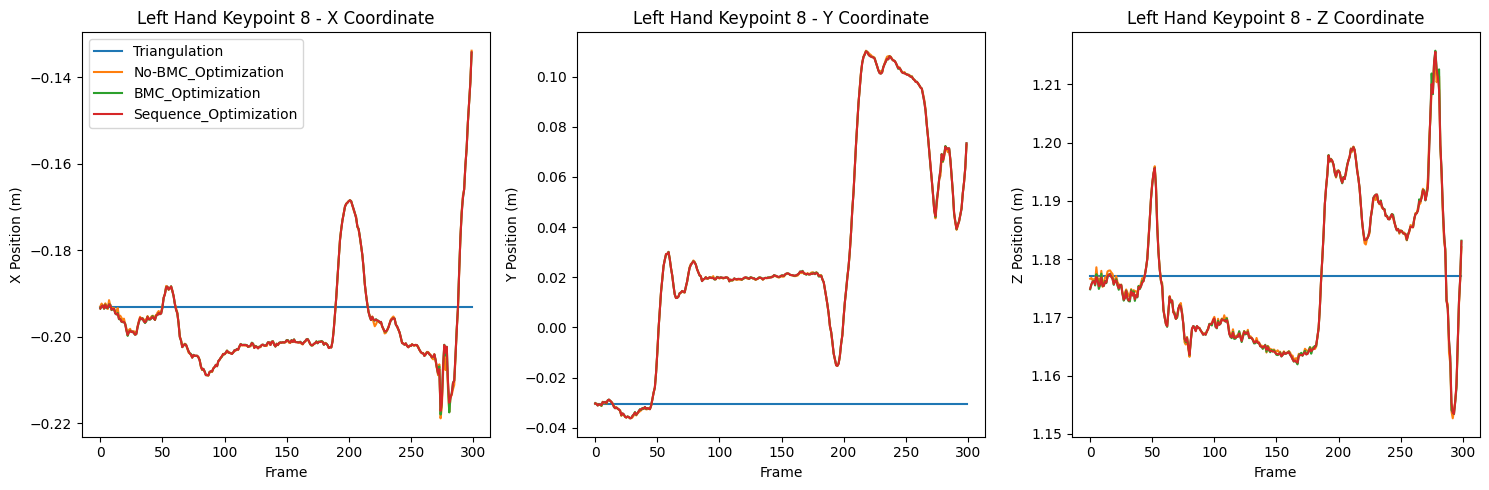

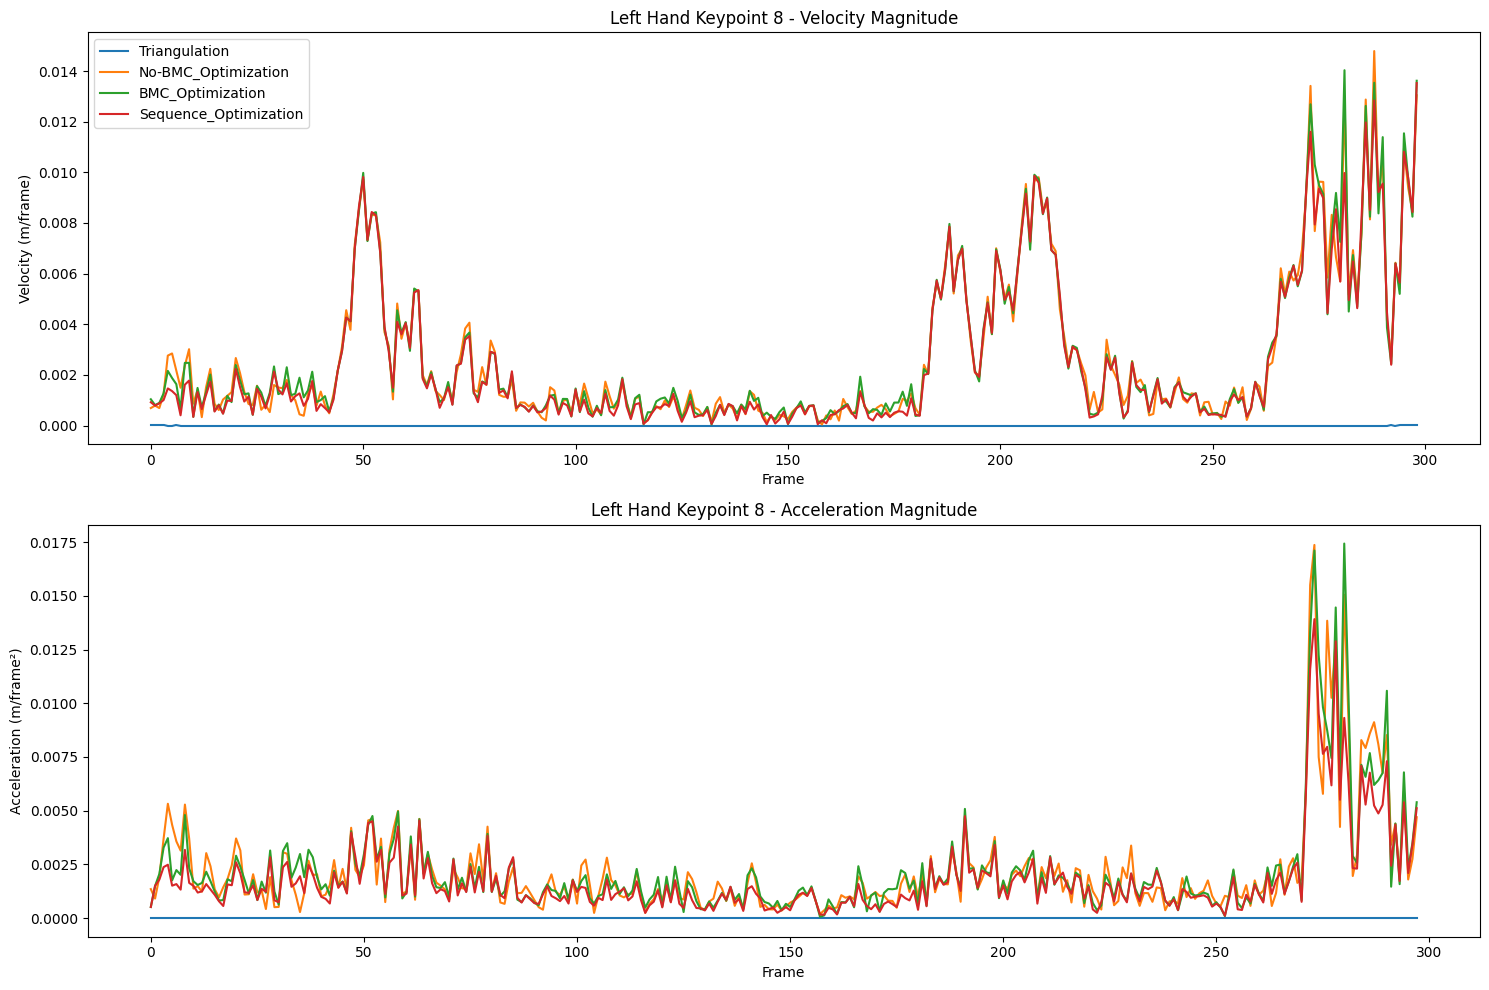

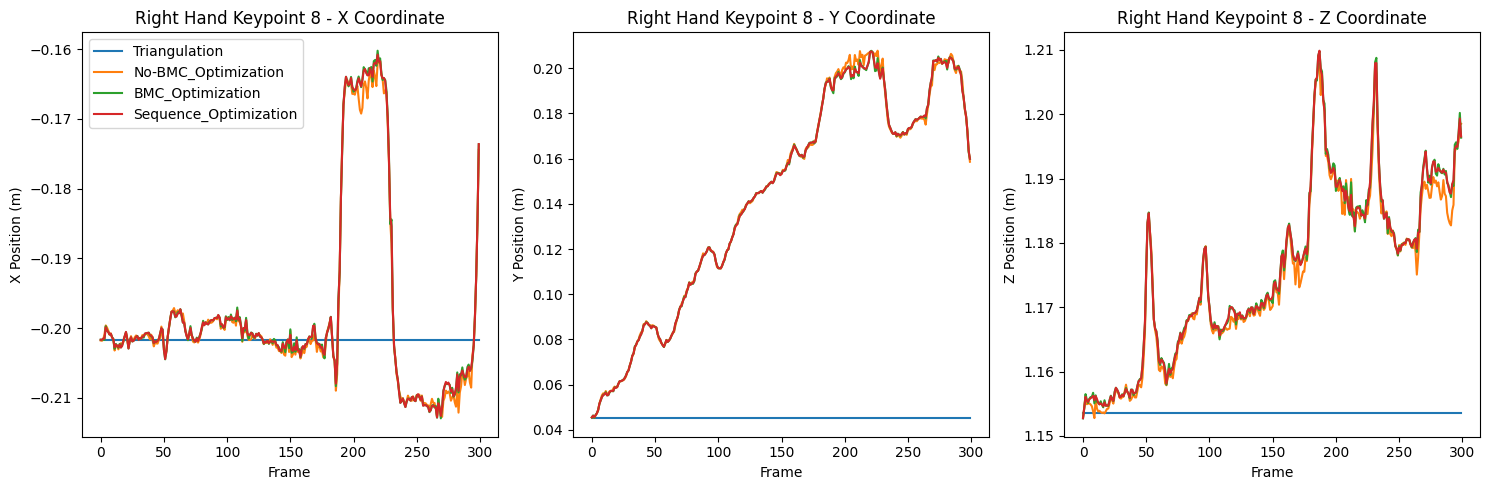

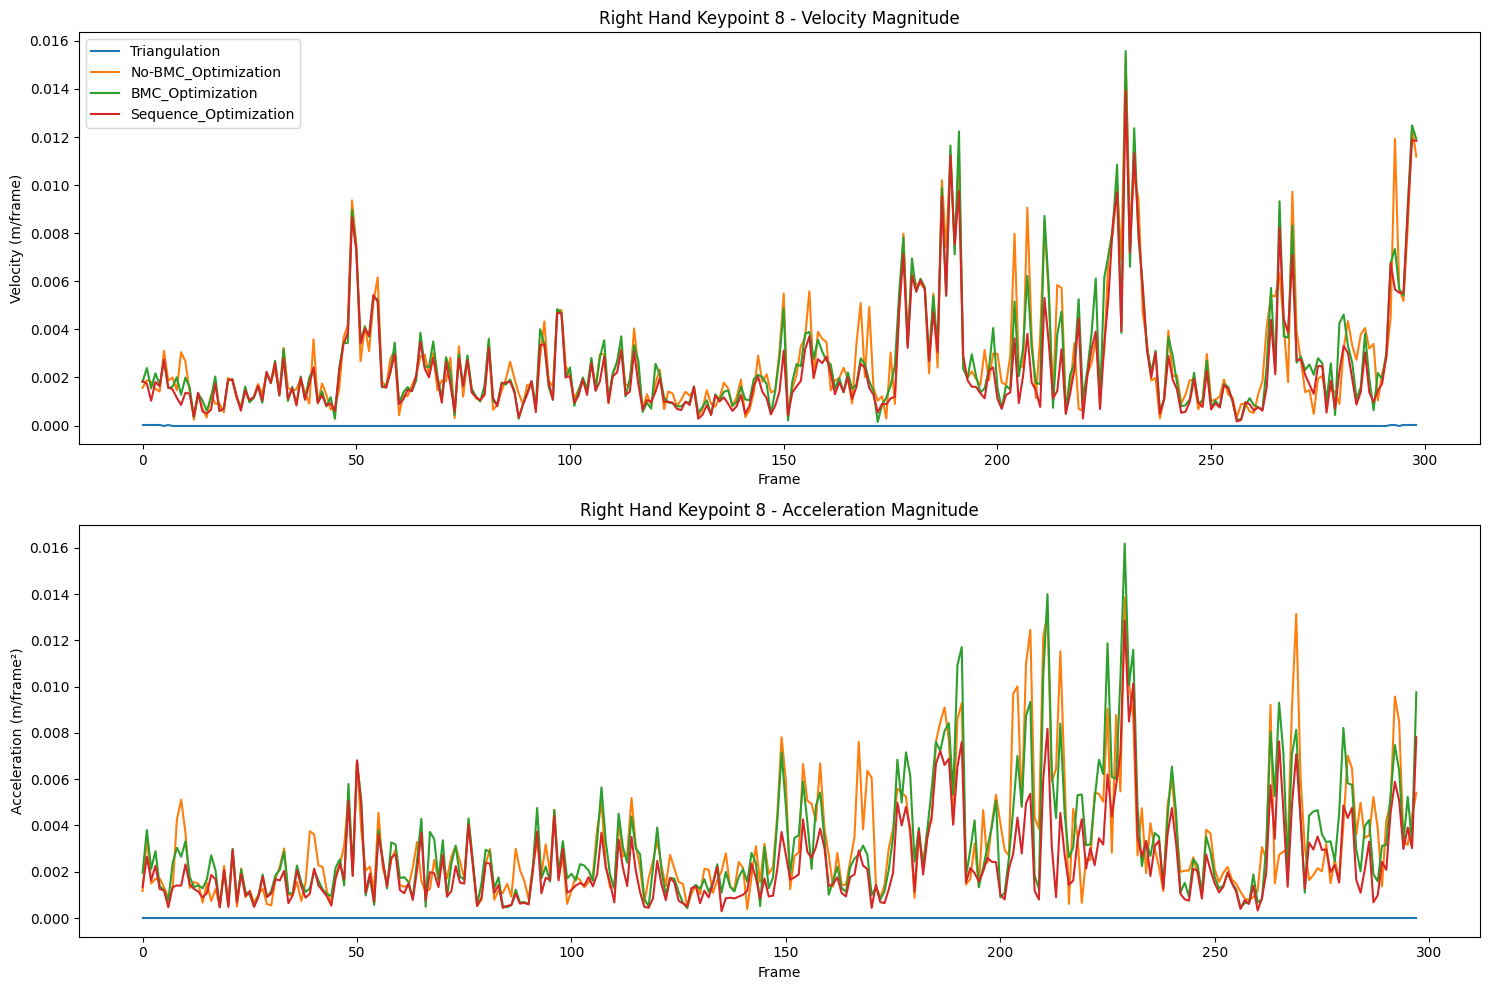

In [ ]:
# Advanced analysis of sequence optimization

# Get person context for multi-person mode
if multiple_people:
    default_person_id = list(poses_3d_body.keys())[0] if isinstance(poses_3d_body, dict) else None
    analysis_suffix = f"_person_{default_person_id}" if default_person_id else ""
    print(f"Performing analysis for Person {default_person_id}" if default_person_id else "No person found for analysis")
else:
    analysis_suffix = ""
    print("Performing analysis for single-person mode")

# Plot trajectory smoothness comparison for a specific keypoint
def plot_keypoint_trajectory(hand_poses_methods_mapped, keypoint_idx=8, hand_side='left'):
    """Plot the 3D trajectory of a specific keypoint across methods."""
    plt.figure(figsize=(15, 5))
    
    # Set up which hand and keypoint to analyze
    if hand_side == 'left':
        kp_idx = keypoint_idx
    else:
        kp_idx = num_keypoints_hands + keypoint_idx
    
    # Plot X coordinate over time
    plt.subplot(1, 3, 1)
    for method_name, poses in hand_poses_methods_mapped.items():
        x_coords = poses[:, kp_idx, 0]
        plt.plot(x_coords, label=method_name)
    title = f'{hand_side.capitalize()} Hand Keypoint {keypoint_idx} - X Coordinate'
    if multiple_people and default_person_id:
        title += f' (Person {default_person_id})'
    plt.title(title)
    plt.xlabel('Frame')
    plt.ylabel('X Position (m)')
    plt.legend()
    
    # Plot Y coordinate over time
    plt.subplot(1, 3, 2)
    for method_name, poses in hand_poses_methods_mapped.items():
        y_coords = poses[:, kp_idx, 1]
        plt.plot(y_coords, label=method_name)
    title = f'{hand_side.capitalize()} Hand Keypoint {keypoint_idx} - Y Coordinate'
    if multiple_people and default_person_id:
        title += f' (Person {default_person_id})'
    plt.title(title)
    plt.xlabel('Frame')
    plt.ylabel('Y Position (m)')
    
    # Plot Z coordinate over time
    plt.subplot(1, 3, 3)
    for method_name, poses in hand_poses_methods_mapped.items():
        z_coords = poses[:, kp_idx, 2]
        plt.plot(z_coords, label=method_name)
    title = f'{hand_side.capitalize()} Hand Keypoint {keypoint_idx} - Z Coordinate'
    if multiple_people and default_person_id:
        title += f' (Person {default_person_id})'
    plt.title(title)
    plt.xlabel('Frame')
    plt.ylabel('Z Position (m)')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'keypoint_{keypoint_idx}_{hand_side}_trajectory_comparison{analysis_suffix}.png'), dpi=300)
    plt.show()

# Calculate velocity and acceleration for each method
def plot_motion_derivatives(hand_poses_methods_mapped, keypoint_idx=8, hand_side='left'):
    """Plot velocity and acceleration profiles for each method."""
    plt.figure(figsize=(15, 10))
    
    # Set up which hand and keypoint to analyze
    if hand_side == 'left':
        kp_idx = keypoint_idx
    else:
        kp_idx = num_keypoints_hands + keypoint_idx
    
    # Plot velocity magnitude over time
    plt.subplot(2, 1, 1)
    for method_name, poses in hand_poses_methods_mapped.items():
        # Calculate velocity as first derivative of position
        velocities = np.linalg.norm(poses[1:, kp_idx] - poses[:-1, kp_idx], axis=1)
        plt.plot(velocities, label=method_name)
    title = f'{hand_side.capitalize()} Hand Keypoint {keypoint_idx} - Velocity Magnitude'
    if multiple_people and default_person_id:
        title += f' (Person {default_person_id})'
    plt.title(title)
    plt.xlabel('Frame')
    plt.ylabel('Velocity (m/frame)')
    plt.legend()
    
    # Plot acceleration magnitude over time
    plt.subplot(2, 1, 2)
    for method_name, poses in hand_poses_methods_mapped.items():
        # Calculate velocity
        velocities = poses[1:, kp_idx] - poses[:-1, kp_idx]
        # Calculate acceleration as first derivative of velocity
        if len(velocities) > 1:
            accelerations = np.linalg.norm(velocities[1:] - velocities[:-1], axis=1)
            plt.plot(accelerations, label=method_name)
    title = f'{hand_side.capitalize()} Hand Keypoint {keypoint_idx} - Acceleration Magnitude'
    if multiple_people and default_person_id:
        title += f' (Person {default_person_id})'
    plt.title(title)
    plt.xlabel('Frame')
    plt.ylabel('Acceleration (m/frame²)')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'keypoint_{keypoint_idx}_{hand_side}_derivatives_comparison{analysis_suffix}.png'), dpi=300)
    plt.show()

# Run the analysis for an index finger tip
keypoint_to_analyze = 8  # Index finger tip
plot_keypoint_trajectory(hand_poses_methods_mapped, keypoint_idx=keypoint_to_analyze, hand_side='left')
plot_motion_derivatives(hand_poses_methods_mapped, keypoint_idx=keypoint_to_analyze, hand_side='left')

# Also analyze the right hand
plot_keypoint_trajectory(hand_poses_methods_mapped, keypoint_idx=keypoint_to_analyze, hand_side='right')
plot_motion_derivatives(hand_poses_methods_mapped, keypoint_idx=keypoint_to_analyze, hand_side='right')